# PLDR — Post-Launch Data Report

**Flight-report template.** Point `FLIGHT_DIR` at a session folder (`flights/<session>/`),
then **Run All**. Every flight's PLDR is one pass of this notebook.

It produces:

1. **Altitude / velocity / acceleration vs time** — from the SD master log (full record)
2. **Apogee, max velocity, descent rate** — peak detection + characteristic descent speeds
3. **GPS ground track + landing distance** — where it flew, how far to walk
4. **Event timeline** — pad → boost → … → landed, with T+ times
5. **Link stats: loss % vs flight phase** — the antenna performance report

### One parser for two logs
The E32 downlink and the onboard SD card carry the **same** `body_t` struct, so a single
codec — `shared/protocol/packet.py` — decodes both. The SD log is the full-rate *master*
record; the downlink (`telemetry.csv`) is a lossy 4 Hz view used for live monitoring and
recovery. This notebook therefore prefers the **SD log for kinematics** and uses the
**received downlink for link stats** (packet loss is a property of the radio link, not the
SD card).

In [1]:
# --- Parameters -----------------------------------------------------------------
# Which flight to analyse. Override without editing by exporting PLDR_FLIGHT_DIR.
import os

FLIGHT_DIR = os.environ.get("PLDR_FLIGHT_DIR", "flights/2026-07-06_sim-01")

# Which source drives the kinematics plots: "sd" | "csv" | "auto".
# "auto" = prefer the SD master log if present, else fall back to the GS telemetry.csv.
PREFER = os.environ.get("PLDR_PREFER", "auto")

In [2]:
# --- Imports + locate the shared codec ------------------------------------------
import sys, json, math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Walk up to the repo root (the dir that contains shared/protocol/packet.py) so we import
# the SAME parser the live backend and the fake-telemetry generator use -- never a copy.
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "shared" / "protocol" / "packet.py").exists():
    if REPO_ROOT == REPO_ROOT.parent:
        raise RuntimeError("Could not find repo root (shared/protocol/packet.py) above cwd")
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from shared.protocol import packet as pk  # noqa: E402  the single source of truth

FLIGHT = (REPO_ROOT / FLIGHT_DIR).resolve()
assert FLIGHT.is_dir(), f"flight folder not found: {FLIGHT}"

plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True,
                     "grid.alpha": 0.3, "figure.dpi": 100})

# Flight-state plotting order + a colour per phase (shared across all charts).
PHASE_ORDER = [s.name for s in pk.FlightState]
PHASE_COLOR = dict(zip(PHASE_ORDER,
                       ["#9aa0a6", "#e8710a", "#f9ab00", "#d93025",
                        "#1a73e8", "#188038", "#5f6368"]))
print(f"repo root : {REPO_ROOT}")
print(f"flight    : {FLIGHT.relative_to(REPO_ROOT)}")

Matplotlib is building the font cache; this may take a moment.


repo root : /Users/sengyongtan0607/Desktop/avionics-ground-station
flight    : flights/2026-07-06_sim-01


## Load — one codec, both logs

`load_binary()` runs the streaming `packet.PacketParser` (the exact framer the backend feeds
serial bytes into) over any raw byte log — the SD card *or* a GS raw capture — and resyncs
past noise / counts CRC errors. `to_csv_row()` defines the column schema, so the binary path
and the CSV path converge on an identical table.

In [3]:
def frames_to_df(telemetry):
    """list[packet.Telemetry] -> DataFrame in the packet.CSV_COLUMNS schema.

    to_csv_row() is the single definition of BOTH the wire fields and the table shape,
    so a binary decode lands in the same columns as a backend-written telemetry.csv."""
    rows = [t.to_csv_row(host_time="", gps_time="") for t in telemetry]
    return pd.DataFrame(rows, columns=pk.CSV_COLUMNS)


def load_binary(path):
    """Decode a raw byte log (SD master or GS raw capture) with the live PacketParser.
    Returns (DataFrame, crc_errors)."""
    data = Path(path).read_bytes()
    parser = pk.PacketParser()
    telemetry = list(parser.feed(data))
    return frames_to_df(telemetry), parser.crc_errors


def load_csv(path):
    """Read a backend-written telemetry.csv (already decoded to engineering units)."""
    return pd.read_csv(path)


def add_derived(df):
    """Attach analysis columns: t_s (onboard seconds) and an ordered phase category."""
    df = df.copy()
    df["t_s"] = df["onboard_ms"] / 1000.0
    df["flight_state"] = df["flight_state"].astype(str)
    df["phase"] = pd.Categorical(df["flight_state"], categories=PHASE_ORDER, ordered=True)
    return df.sort_values("onboard_ms").reset_index(drop=True)

In [4]:
# Discover the files this session actually has.
sd_bin   = next((p for p in [FLIGHT / "sd_log.bin", *sorted(FLIGHT.glob("*.bin"))]
                 if p.exists()), None)
csv_path = FLIGHT / "telemetry.csv"
meta = json.loads((FLIGHT / "metadata.json").read_text()) if (FLIGHT / "metadata.json").exists() else {}

# GS downlink (received packets; the lossy view) -- drives LINK stats.
gs = add_derived(load_csv(csv_path)) if csv_path.exists() else None

# SD master (complete record) -- drives KINEMATICS.
sd, sd_crc_errors = (None, 0)
if sd_bin is not None:
    sd_df, sd_crc_errors = load_binary(sd_bin)
    sd = add_derived(sd_df)

# Choose the kinematics source.
if PREFER == "csv" or (PREFER == "auto" and sd is None):
    master, master_name = gs, "GS downlink (telemetry.csv)"
elif PREFER == "sd" or (PREFER == "auto" and sd is not None):
    master, master_name = sd, f"SD master ({sd_bin.name})"
assert master is not None, "no usable telemetry source in this flight folder"

print(f"SD master   : {'%d rows' % len(sd) if sd is not None else '— (none)'}"
      f"   crc_errors={sd_crc_errors}")
print(f"GS downlink : {'%d rows' % len(gs) if gs is not None else '— (none)'}")
print(f"kinematics from: {master_name}   ({len(master)} rows)")
if meta:
    print(f"metadata: session={meta.get('session')} simulated={meta.get('simulated')} "
          f"air_rate={meta.get('air_rate_bps')} bps")

SD master   : 450 rows   crc_errors=0
GS downlink : 417 rows
kinematics from: SD master (sd_log.bin)   (450 rows)
metadata: session=2026-07-06_sim-01 simulated=True air_rate=2400 bps


## 1 · Altitude / velocity / acceleration vs time

Altitude and vertical speed are read straight from the log; **acceleration is derived**
(`d(vspeed)/dt`). Finite-differencing 4 Hz data amplifies steps, so the accel trace is
noisier than the others — on real flights the SD card's high-rate IMU is the better source
for g-loads. Phase bands are shaded; the dashed line marks apogee.

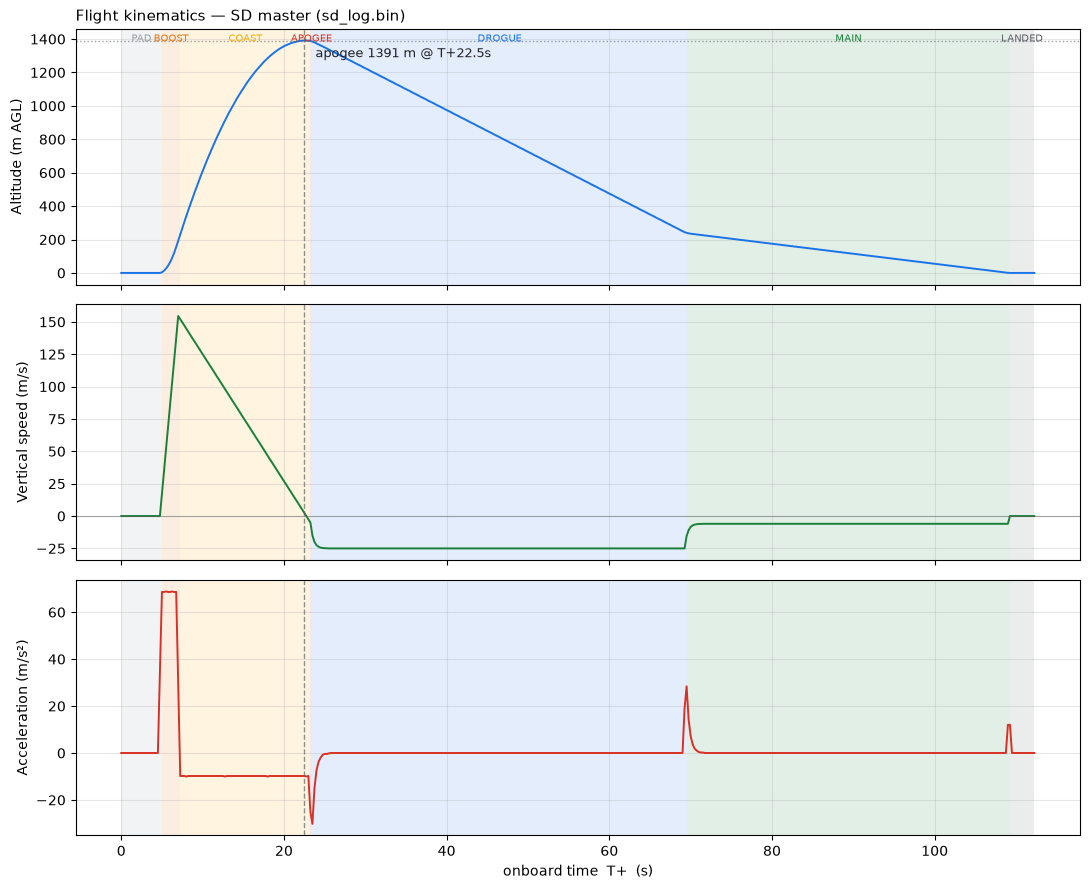

In [5]:
def phase_spans(df):
    """Yield (state_name, t_start, t_end) contiguous runs for axvspan shading."""
    runs, start_i = [], 0
    states = df["flight_state"].to_numpy()
    t = df["t_s"].to_numpy()
    for i in range(1, len(df)):
        if states[i] != states[start_i]:
            runs.append((states[start_i], t[start_i], t[i]))
            start_i = i
    runs.append((states[start_i], t[start_i], t[-1]))
    return runs


def shade_phases(ax, df, label=False):
    for name, t0, t1 in phase_spans(df):
        ax.axvspan(t0, t1, color=PHASE_COLOR.get(name, "#ccc"), alpha=0.12, lw=0)
        if label:
            ax.text((t0 + t1) / 2, 0.98, name, transform=ax.get_xaxis_transform(),
                    ha="center", va="top", fontsize=7, color=PHASE_COLOR.get(name, "#666"))

t = master["t_s"].to_numpy()
alt = master["baro_alt_m"].to_numpy(dtype=float)
vel = master["vspeed_ms"].to_numpy(dtype=float)
accel = np.gradient(vel, t)  # m/s^2

apogee_i = int(np.argmax(alt))
apogee_t, apogee_alt = t[apogee_i], alt[apogee_i]

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
series = [("Altitude (m AGL)", alt, "#1a73e8"),
          ("Vertical speed (m/s)", vel, "#188038"),
          ("Acceleration (m/s²)", accel, "#d93025")]
for ax, (label, y, c) in zip(axes, series):
    ax.plot(t, y, color=c, lw=1.4)
    ax.set_ylabel(label)
    shade_phases(ax, master, label=(ax is axes[0]))
    ax.axvline(apogee_t, ls="--", color="#5f6368", lw=1, alpha=0.7)
axes[0].axhline(apogee_alt, ls=":", color="#5f6368", lw=1, alpha=0.6)
axes[0].annotate(f"apogee {apogee_alt:.0f} m @ T+{apogee_t:.1f}s",
                 (apogee_t, apogee_alt), textcoords="offset points", xytext=(8, -12),
                 fontsize=9, color="#202124")
axes[1].axhline(0, color="#5f6368", lw=0.8, alpha=0.5)
axes[-1].set_xlabel("onboard time  T+  (s)")
axes[0].set_title(f"Flight kinematics — {master_name}", loc="left", fontsize=11)
plt.tight_layout()
plt.show()

## 2 · Apogee, max velocity, descent rate

Apogee is the barometric peak (cross-checked against the flight computer's `APOGEE` state
marker). Descent rates are the **median** vertical speed within each descent phase — median,
not mean, so a couple of noisy samples at deploy transients don't skew the terminal-velocity
estimate.

> *Tuning lever:* `descent_rate()` below characterises each descent phase. If you'd rather
> report, say, the 10th-percentile (worst-case) sink rate or a settled-window mean, this is
> the natural place to shape the metric.

In [6]:
def descent_rate(df, state_name):
    """Median vertical speed (m/s, negative = down) while in a given descent phase.
    Returns np.nan if that phase never occurred in this flight."""
    seg = df.loc[df["flight_state"] == state_name, "vspeed_ms"]
    return float(seg.median()) if len(seg) else float("nan")


max_vel = float(np.max(vel))
max_vel_t = float(t[int(np.argmax(vel))])
touchdown_v = descent_rate(master, "MAIN")  # sink rate just before landing

# Cross-check the barometric apogee against the onboard state machine's APOGEE marker.
apogee_marker = master.loc[master["flight_state"] == "APOGEE", "t_s"]
marker_t = float(apogee_marker.iloc[0]) if len(apogee_marker) else float("nan")

summary = pd.DataFrame(
    [("Apogee altitude (baro)", f"{apogee_alt:.0f} m AGL", f"T+{apogee_t:.2f}s"),
     ("Apogee (state marker)", "APOGEE", f"T+{marker_t:.2f}s" if marker_t == marker_t else "—"),
     ("Max velocity", f"{max_vel:.1f} m/s", f"T+{max_vel_t:.2f}s   (Mach {max_vel/343:.2f})"),
     ("Max acceleration", f"{np.nanmax(accel):.1f} m/s²", f"{np.nanmax(accel)/9.81:.1f} g"),
     ("Drogue descent rate", f"{descent_rate(master, 'DROGUE'):.1f} m/s", "median"),
     ("Main descent rate", f"{descent_rate(master, 'MAIN'):.1f} m/s", "median"),
     ("Touchdown sink rate", f"{touchdown_v:.1f} m/s", "under main")],
    columns=["metric", "value", "note"])
summary.style.hide(axis="index")

metric,value,note
Apogee altitude (baro),1391 m AGL,T+22.50s
Apogee (state marker),APOGEE,T+23.25s
Max velocity,154.5 m/s,T+7.00s (Mach 0.45)
Max acceleration,68.8 m/s²,7.0 g
Drogue descent rate,-25.0 m/s,median
Main descent rate,-6.0 m/s,median
Touchdown sink rate,-6.0 m/s,under main


## 3 · GPS ground track + landing distance

The launch reference is the first valid 3-D fix (where it sat on the pad); the landing point
is the last fix. Distance is the **haversine** great-circle range — what you'll walk to
recover the airframe — with the initial bearing for a compass heading.

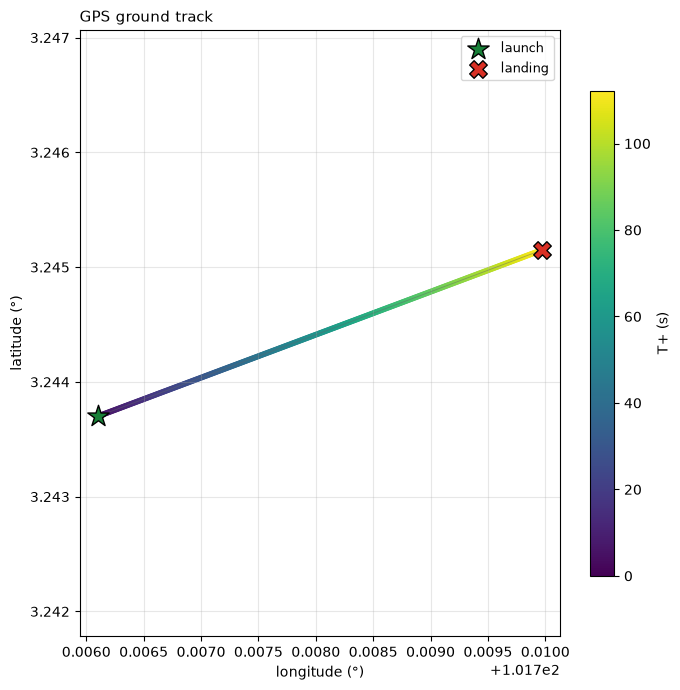

Landing distance :  458.7 m  bearing  69° from launch
Max downrange    :  458.7 m
Last known fix   : 3.245148, 101.709969  (11 sats, fix 3D)


In [7]:
def haversine_m(lat1, lon1, lat2, lon2):
    """Great-circle distance in metres between two decimal-degree points."""
    R = 6_371_000.0
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dp, dl = math.radians(lat2 - lat1), math.radians(lon2 - lon1)
    a = math.sin(dp / 2) ** 2 + math.cos(p1) * math.cos(p2) * math.sin(dl / 2) ** 2
    return 2 * R * math.asin(math.sqrt(a))


def bearing_deg(lat1, lon1, lat2, lon2):
    """Initial compass bearing (° from true north) from point 1 to point 2."""
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dl = math.radians(lon2 - lon1)
    y = math.sin(dl) * math.cos(p2)
    x = math.cos(p1) * math.sin(p2) - math.sin(p1) * math.cos(p2) * math.cos(dl)
    return (math.degrees(math.atan2(y, x)) + 360) % 360


# Valid fixes only: gps_fix >= 2 and not a null (0,0) island.
gps = master[(master["gps_fix"] >= 2) &
             ~((master["gps_lat"] == 0) & (master["gps_lon"] == 0))].copy()
assert len(gps) >= 2, "not enough GPS fixes to plot a track"

pad = gps.iloc[0]
land = gps.iloc[-1]
dist = haversine_m(pad.gps_lat, pad.gps_lon, land.gps_lat, land.gps_lon)
brg = bearing_deg(pad.gps_lat, pad.gps_lon, land.gps_lat, land.gps_lon)
downrange = gps.apply(lambda r: haversine_m(pad.gps_lat, pad.gps_lon, r.gps_lat, r.gps_lon),
                      axis=1)

fig, ax = plt.subplots(figsize=(7, 7))
sc = ax.scatter(gps["gps_lon"], gps["gps_lat"], c=gps["t_s"], cmap="viridis", s=10)
ax.plot(gps["gps_lon"], gps["gps_lat"], color="#5f6368", lw=0.6, alpha=0.5)
ax.scatter([pad.gps_lon], [pad.gps_lat], marker="*", s=260, color="#188038",
           edgecolor="k", zorder=5, label="launch")
ax.scatter([land.gps_lon], [land.gps_lat], marker="X", s=160, color="#d93025",
           edgecolor="k", zorder=5, label="landing")
ax.set_aspect("equal", adjustable="datalim")
ax.set_xlabel("longitude (°)"); ax.set_ylabel("latitude (°)")
ax.set_title("GPS ground track", loc="left", fontsize=11)
ax.legend(loc="best", fontsize=9)
fig.colorbar(sc, ax=ax, label="T+ (s)", shrink=0.8)
plt.tight_layout(); plt.show()

print(f"Landing distance : {dist:6.1f} m  bearing {brg:3.0f}° from launch")
print(f"Max downrange    : {downrange.max():6.1f} m")
print(f"Last known fix   : {land.gps_lat:.6f}, {land.gps_lon:.6f}  "
      f"({int(land.gps_sats)} sats, fix {int(land.gps_fix)}D)")

## 4 · Event timeline

Prefers the backend-written `events.csv` (the timestamps logged live); otherwise it's
reconstructed from flight-state transitions in the master log. `T+` is measured from first
motion (`BOOST`).

In [8]:
def timeline_from_master(df):
    """Reconstruct state-transition events if events.csv is absent."""
    ch = df[df["flight_state"].ne(df["flight_state"].shift())]
    return pd.DataFrame({"event": "state:" + ch["flight_state"],
                         "onboard_ms": ch["onboard_ms"], "seq": ch["seq"],
                         "flight_state": ch["flight_state"],
                         "baro_alt_m": ch["baro_alt_m"], "vspeed_ms": ch["vspeed_ms"]})


events_csv = FLIGHT / "events.csv"
events = pd.read_csv(events_csv) if events_csv.exists() else timeline_from_master(master)

# T+ from first motion (BOOST), the conventional liftoff reference.
boost = events.loc[events["flight_state"] == "BOOST", "onboard_ms"]
t0_ms = int(boost.iloc[0]) if len(boost) else int(events["onboard_ms"].min())
events = events.copy()
events.insert(1, "T_plus_s", (events["onboard_ms"] - t0_ms) / 1000.0)

show_cols = [c for c in ["event", "T_plus_s", "onboard_ms", "seq",
                         "flight_state", "baro_alt_m", "vspeed_ms"] if c in events.columns]
events[show_cols].style.hide(axis="index").format({"T_plus_s": "{:+.2f}"})

event,T_plus_s,onboard_ms,seq,flight_state,baro_alt_m,vspeed_ms
state:PAD,-5.00,0,1,PAD,0,0.000000
state:BOOST,+0.00,5000,21,BOOST,4,17.200000
state:COAST,+2.25,7250,30,COAST,231,152.100000
state:APOGEE,+18.25,23250,94,APOGEE,1389,-4.900000
state:DROGUE,+18.50,23500,95,DROGUE,1385,-15.000000
pyro_fired,+18.50,23500,95,DROGUE,1385,-15.000000
state:MAIN,+64.50,69500,279,MAIN,240,-15.500000
state:LANDED,+104.25,109250,438,LANDED,0,0.000000


## 5 · Link stats — loss % vs flight phase

The E32 has **no RSSI output**, so link quality is inferred purely from the `seq` counter on
**received** packets: a jump of *n* in `seq` means *n−1* packets were lost between them. Loss
is attributed to the phase of the packet that arrived after the gap, giving a per-phase
breakdown — effectively an **antenna-performance report**. Expect the worst loss under
`DROGUE`, when the tumbling airframe swings the antenna through nulls.

> *Tuning lever:* the attribution rule (gap → which phase) is a modelling choice. Attributing
> to the *following* packet's phase is one convention; splitting a gap across a phase boundary
> is another. Adjust in the cell below if your antenna study needs it.

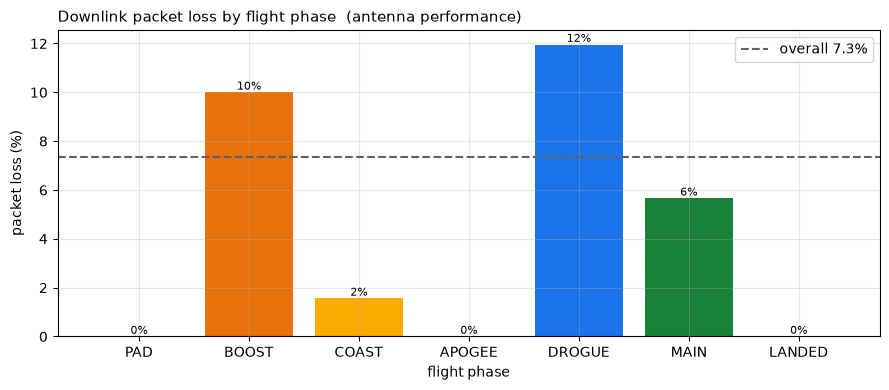

,received,lost,expected,loss_pct
PAD,19,0,19,0.0%
BOOST,9,1,10,10.0%
COAST,63,1,64,1.6%
APOGEE,1,0,1,0.0%
DROGUE,162,22,184,12.0%
MAIN,150,9,159,5.7%
LANDED,13,0,13,0.0%
TOTAL,417,33,450,7.3%


In [9]:
assert gs is not None, "link stats need the received downlink (telemetry.csv)"

link = gs.sort_values("seq").reset_index(drop=True).copy()
# seq gap with u16 wrap handled (65535 -> 0 is a gap of 1, not -65535).
gap = link["seq"].diff()
gap[gap < 0] += 65536
link["lost_before"] = (gap - 1).clip(lower=0).fillna(0)

by_phase = (link.groupby("flight_state")
                .agg(received=("seq", "size"), lost=("lost_before", "sum")))
by_phase["expected"] = by_phase["received"] + by_phase["lost"]
by_phase["loss_pct"] = 100 * by_phase["lost"] / by_phase["expected"]
by_phase = by_phase.reindex([s for s in PHASE_ORDER if s in by_phase.index])

total = pd.DataFrame({"received": [by_phase["received"].sum()],
                      "lost": [by_phase["lost"].sum()],
                      "expected": [by_phase["expected"].sum()]}, index=["TOTAL"])
total["loss_pct"] = 100 * total["lost"] / total["expected"]
table = pd.concat([by_phase, total])

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(by_phase.index, by_phase["loss_pct"],
              color=[PHASE_COLOR.get(s, "#ccc") for s in by_phase.index])
ax.axhline(total["loss_pct"].iloc[0], ls="--", color="#5f6368",
           label=f"overall {total['loss_pct'].iloc[0]:.1f}%")
ax.set_ylabel("packet loss (%)"); ax.set_xlabel("flight phase")
ax.set_title("Downlink packet loss by flight phase  (antenna performance)", loc="left", fontsize=11)
for b, v in zip(bars, by_phase["loss_pct"]):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:.0f}%", ha="center", va="bottom", fontsize=8)
ax.legend(); plt.tight_layout(); plt.show()

table.assign(lost=lambda d: d["lost"].astype(int),
             expected=lambda d: d["expected"].astype(int)) \
     .style.format({"loss_pct": "{:.1f}%"})

In [10]:
# --- One-line PLDR summary ------------------------------------------------------
dur = master["t_s"].iloc[-1] - master["t_s"].iloc[0]
vbat_drop = master["vbat_v"].iloc[0] - master["vbat_v"].min()
print("── PLDR SUMMARY " + "─" * 50)
print(f"  session          {meta.get('session', FLIGHT.name)}")
print(f"  flight duration  {dur:.1f} s")
print(f"  apogee           {apogee_alt:.0f} m AGL  @ T+{apogee_t:.1f}s")
print(f"  max velocity     {max_vel:.1f} m/s  (Mach {max_vel/343:.2f})")
print(f"  landing distance {dist:.0f} m  bearing {brg:.0f}°")
print(f"  downlink loss    {total['loss_pct'].iloc[0]:.1f}% overall "
      f"(worst phase: {by_phase['loss_pct'].idxmax()} {by_phase['loss_pct'].max():.0f}%)")
print(f"  SD crc errors    {sd_crc_errors}")
print(f"  battery droop    {vbat_drop:.2f} V")
print("─" * 65)

── PLDR SUMMARY ──────────────────────────────────────────────────
  session          2026-07-06_sim-01
  flight duration  112.2 s
  apogee           1391 m AGL  @ T+22.5s
  max velocity     154.5 m/s  (Mach 0.45)
  landing distance 459 m  bearing 69°
  downlink loss    7.3% overall (worst phase: DROGUE 12%)
  SD crc errors    0
  battery droop    0.30 V
─────────────────────────────────────────────────────────────────
